# Analyse des données DVF (Demande de valeur fonciere)

### Importation des dépendances

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import zipfile
import os
import glob
import shutil
import time
import requests
import json
from pathlib import Path

#from config import DATA_DIR

In [92]:
ROUT = Path(os.path.abspath('')).parent
DATA_DIR = ROUT / "data"


In [93]:
print(ROUT)

c:\Users\dd758\Formation_IA_Greta\formation_alternance\projet_immo\Projet-immo


In [94]:
dvf_file = DATA_DIR / 'valeursfoncieres-2025-s1.txt.zip' #gerer les chemins entre windows et linux

In [95]:
df = pd.read_csv(dvf_file, compression='zip', sep='|', decimal=',')

C:\Users\dd758\AppData\Local\Temp\ipykernel_13948\455709868.py:1: DtypeWarning: Columns (18,23,24,26,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dvf_file, compression='zip', sep='|', decimal=',')


In [96]:
df.head()

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,J,NaN,78.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,...,NaN,0,1.0,Maison,NaN,111.0,5.0,S,NaN,133.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,...,NaN,0,3.0,Dépendance,NaN,0.0,0.0,S,NaN,133.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2025,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,S,NaN,46.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2025,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,J,NaN,17.0


#### Type de données dans chaque colonnes

In [ ]:
df[df["Prefixe de section"]=='NaN']

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1387077 entries, 0 to 1387076
Data columns (total 43 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Identifiant de document     0 non-null        float64
 1   Reference document          0 non-null        float64
 2   1 Articles CGI              0 non-null        float64
 3   2 Articles CGI              0 non-null        float64
 4   3 Articles CGI              0 non-null        float64
 5   4 Articles CGI              0 non-null        float64
 6   5 Articles CGI              0 non-null        float64
 7   No disposition              1387077 non-null  int64  
 8   Date mutation               1387077 non-null  object 
 9   Nature mutation             1387077 non-null  object 
 10  Valeur fonciere             1373082 non-null  float64
 11  No voie                     873098 non-null   float64
 12  B/T/Q                       64520 non-null    object 
 1

#### Valeur de données manquante

In [98]:
df.isnull().sum()

Identifiant de document       1387077
Reference document            1387077
1 Articles CGI                1387077
2 Articles CGI                1387077
3 Articles CGI                1387077
4 Articles CGI                1387077
5 Articles CGI                1387077
No disposition                      0
Date mutation                       0
Nature mutation                     0
Valeur fonciere                 13995
No voie                        513979
B/T/Q                         1322557
Type de voie                   542232
Code voie                       12158
Voie                            12171
Code postal                     12231
Commune                             0
Code departement                    0
Code commune                        0
Prefixe de section            1316580
Section                            56
No plan                             0
No Volume                     1384014
1er lot                        944993
Surface Carrez du 1er lot     1251644
2eme lot    

<Axes: >

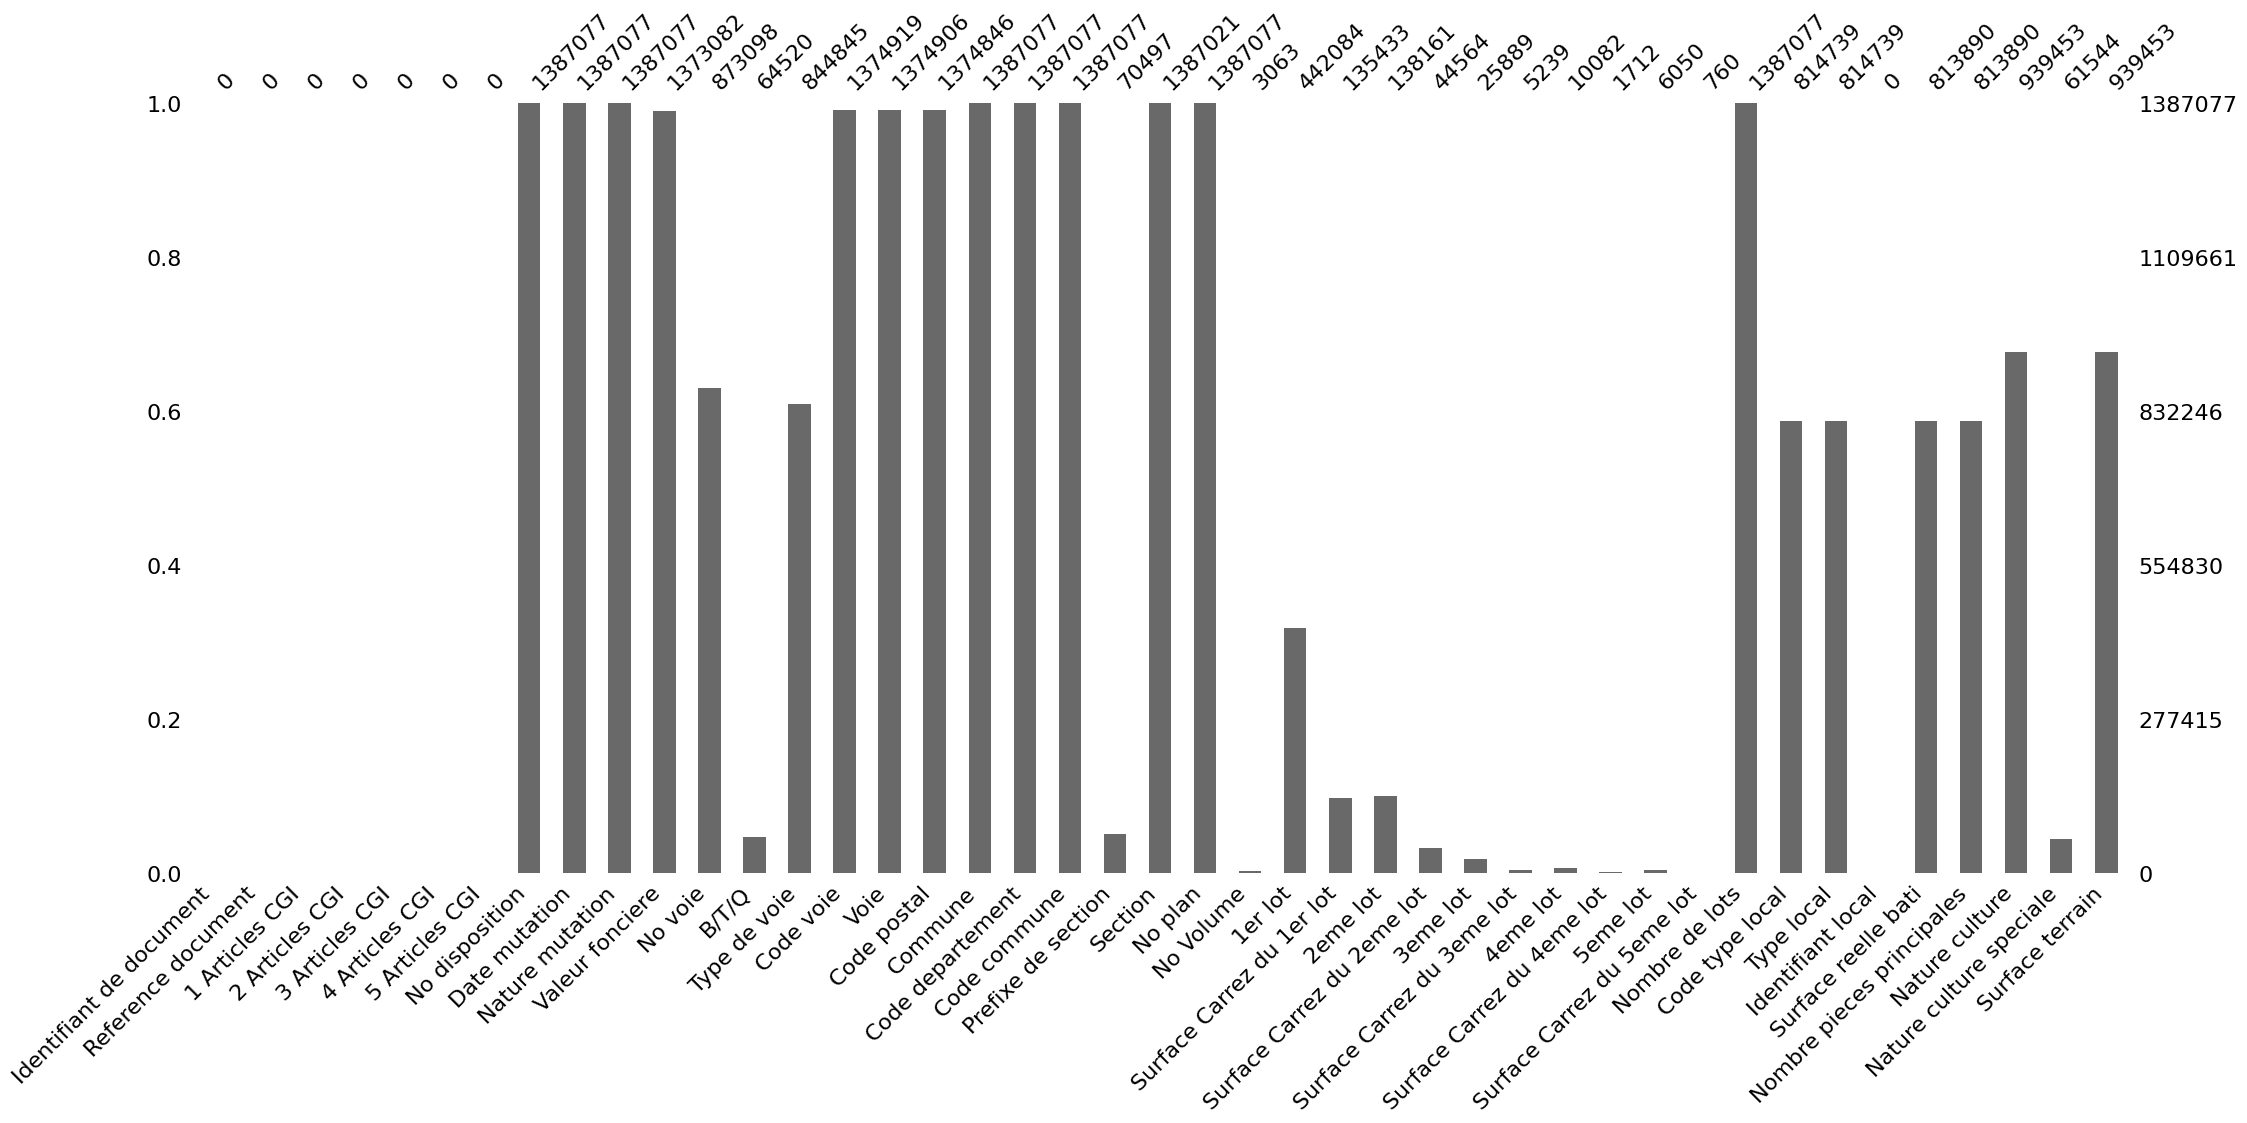

In [99]:
msno.bar(df)

<Axes: >

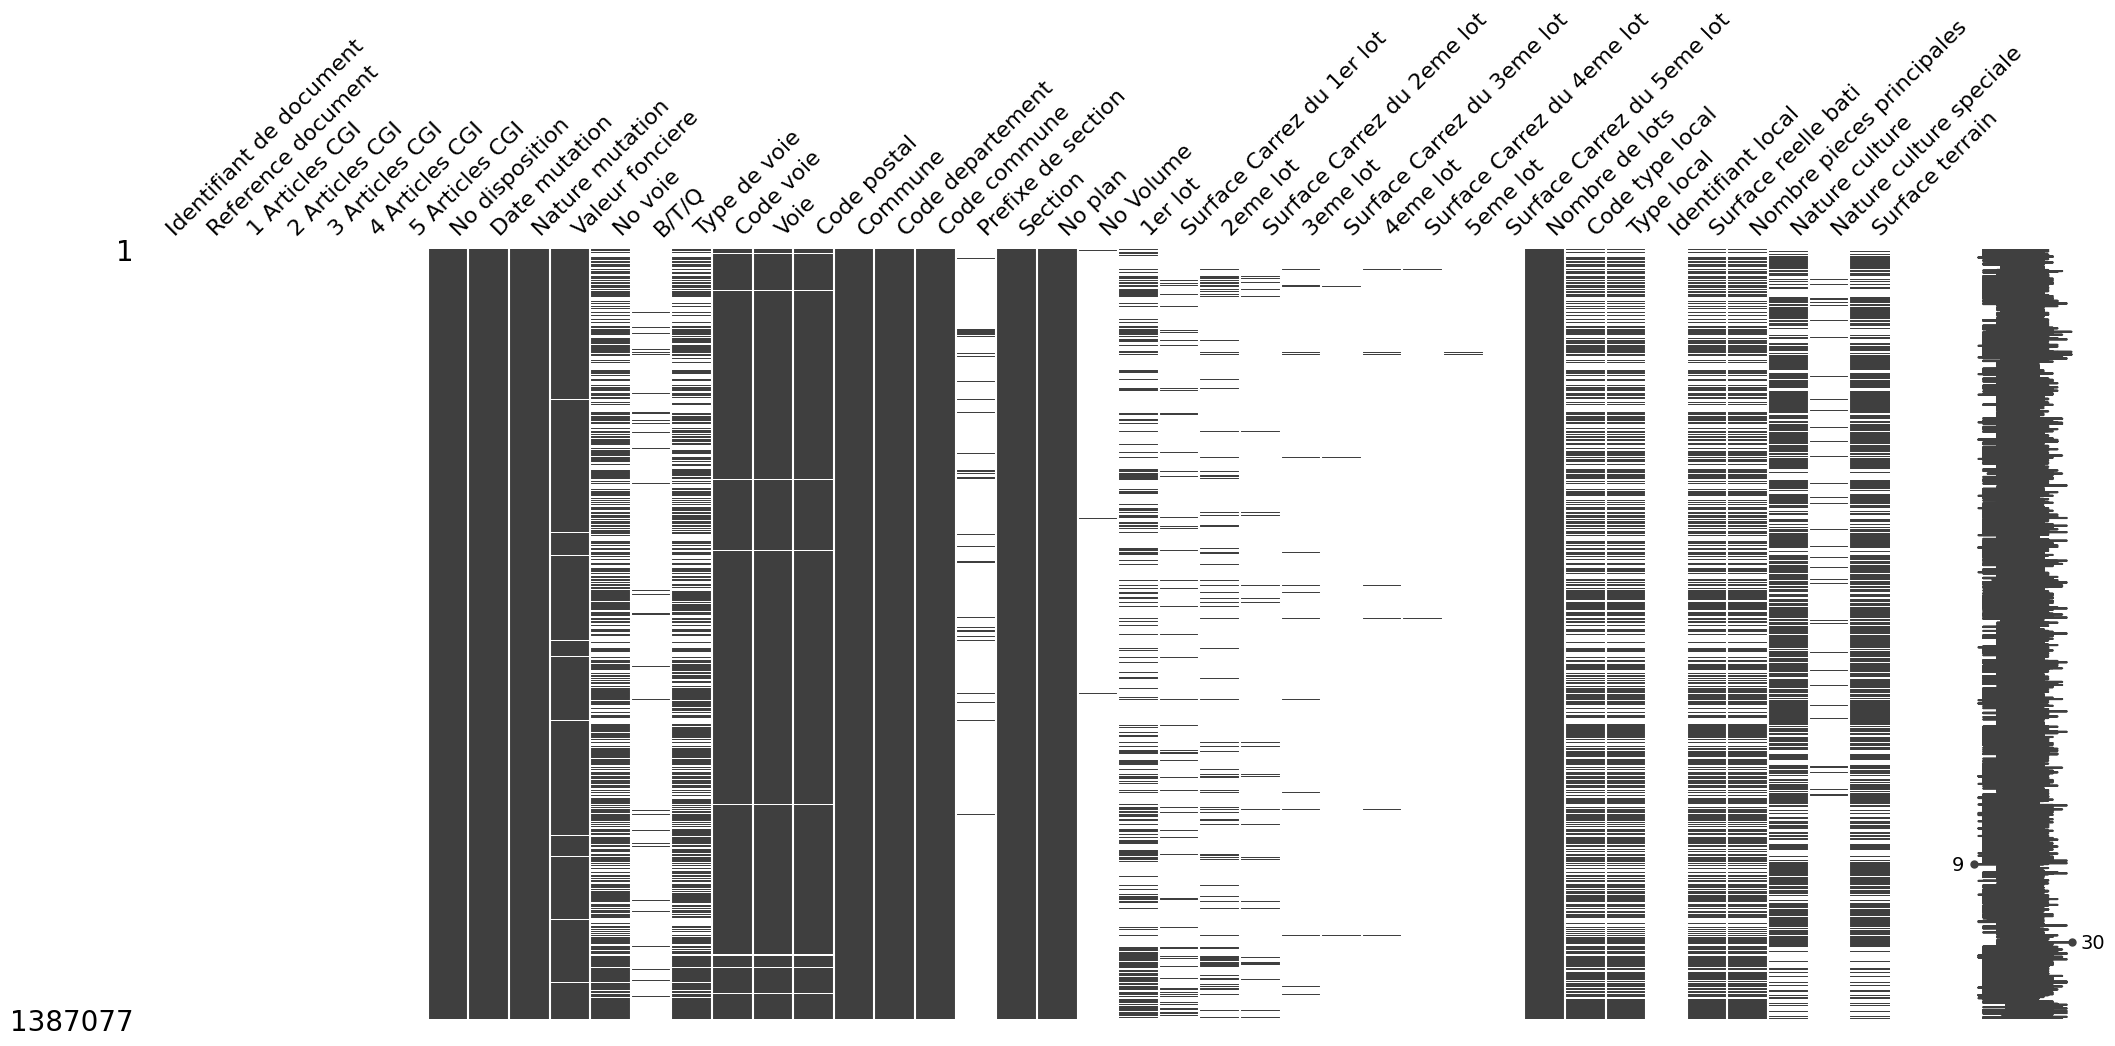

In [100]:
msno.matrix(df)

<Axes: >

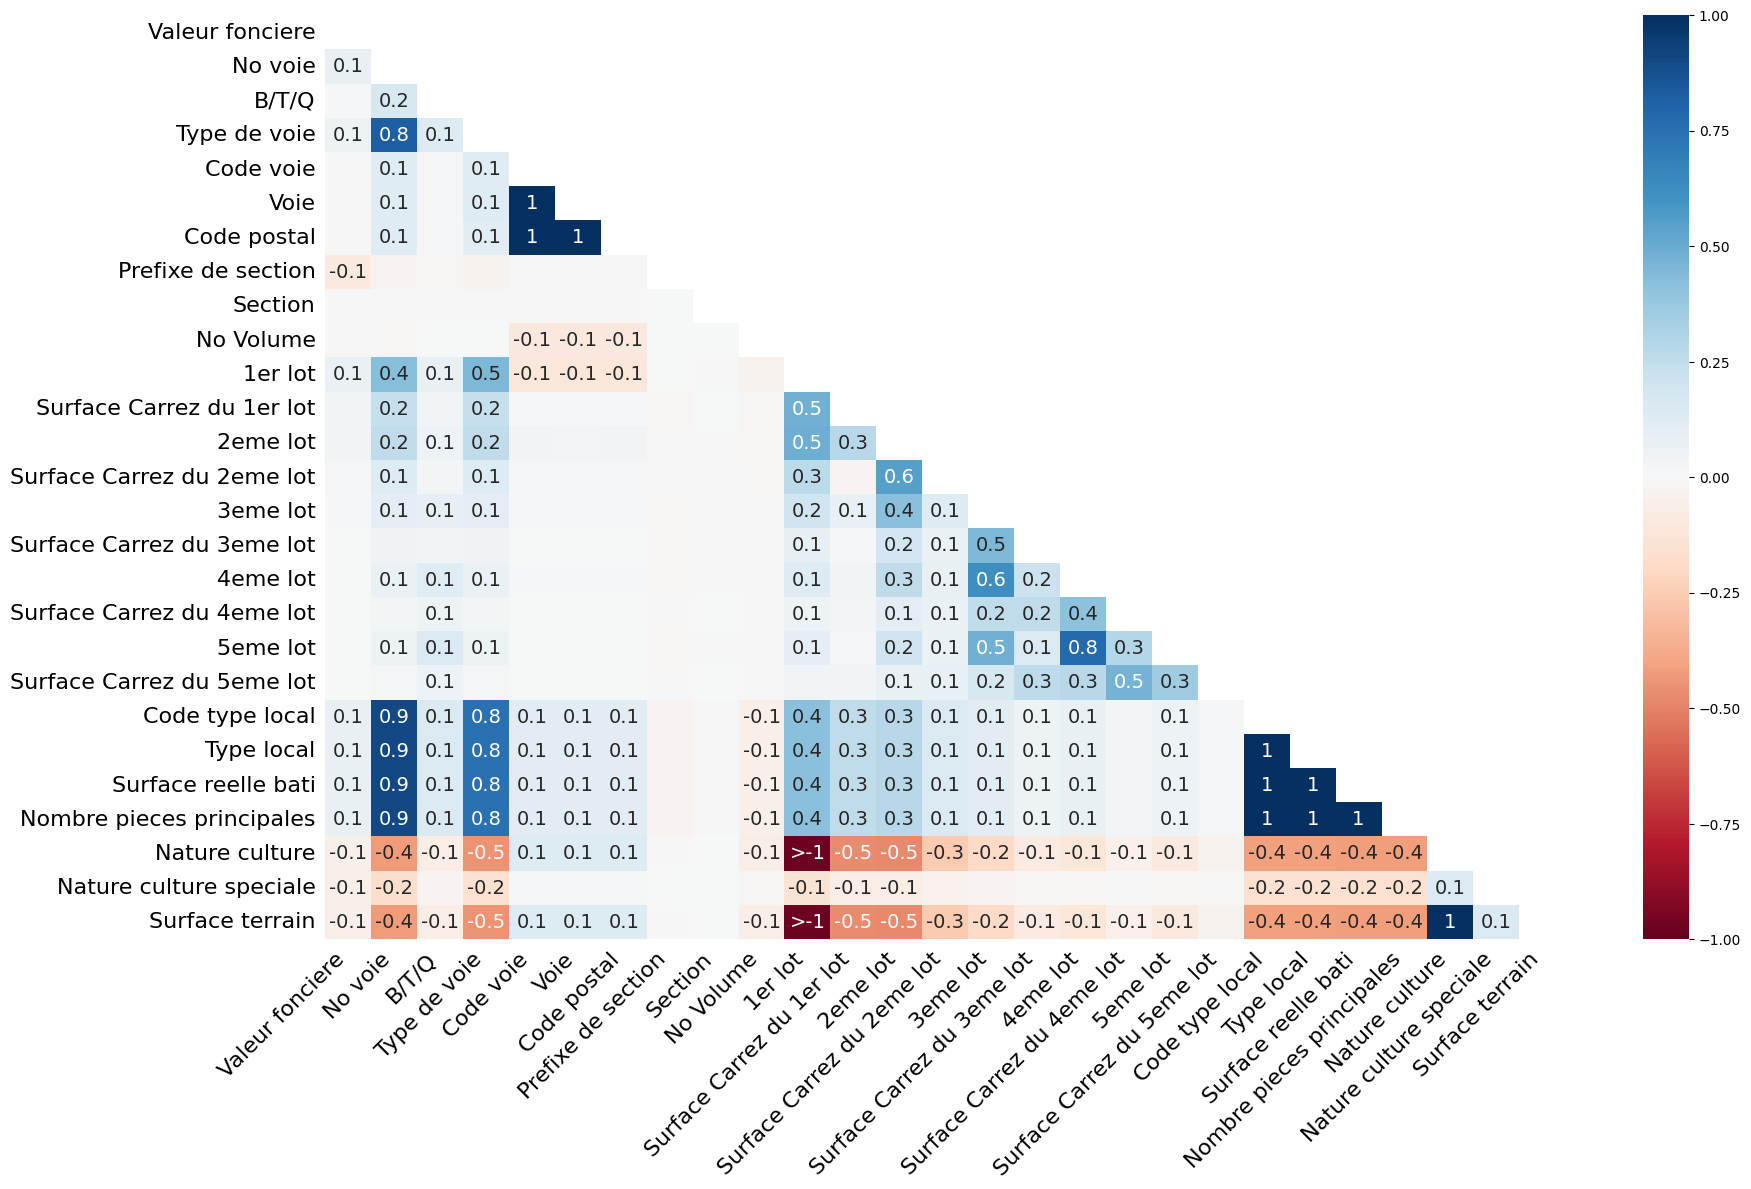

In [101]:
msno.heatmap(df)

<Axes: >

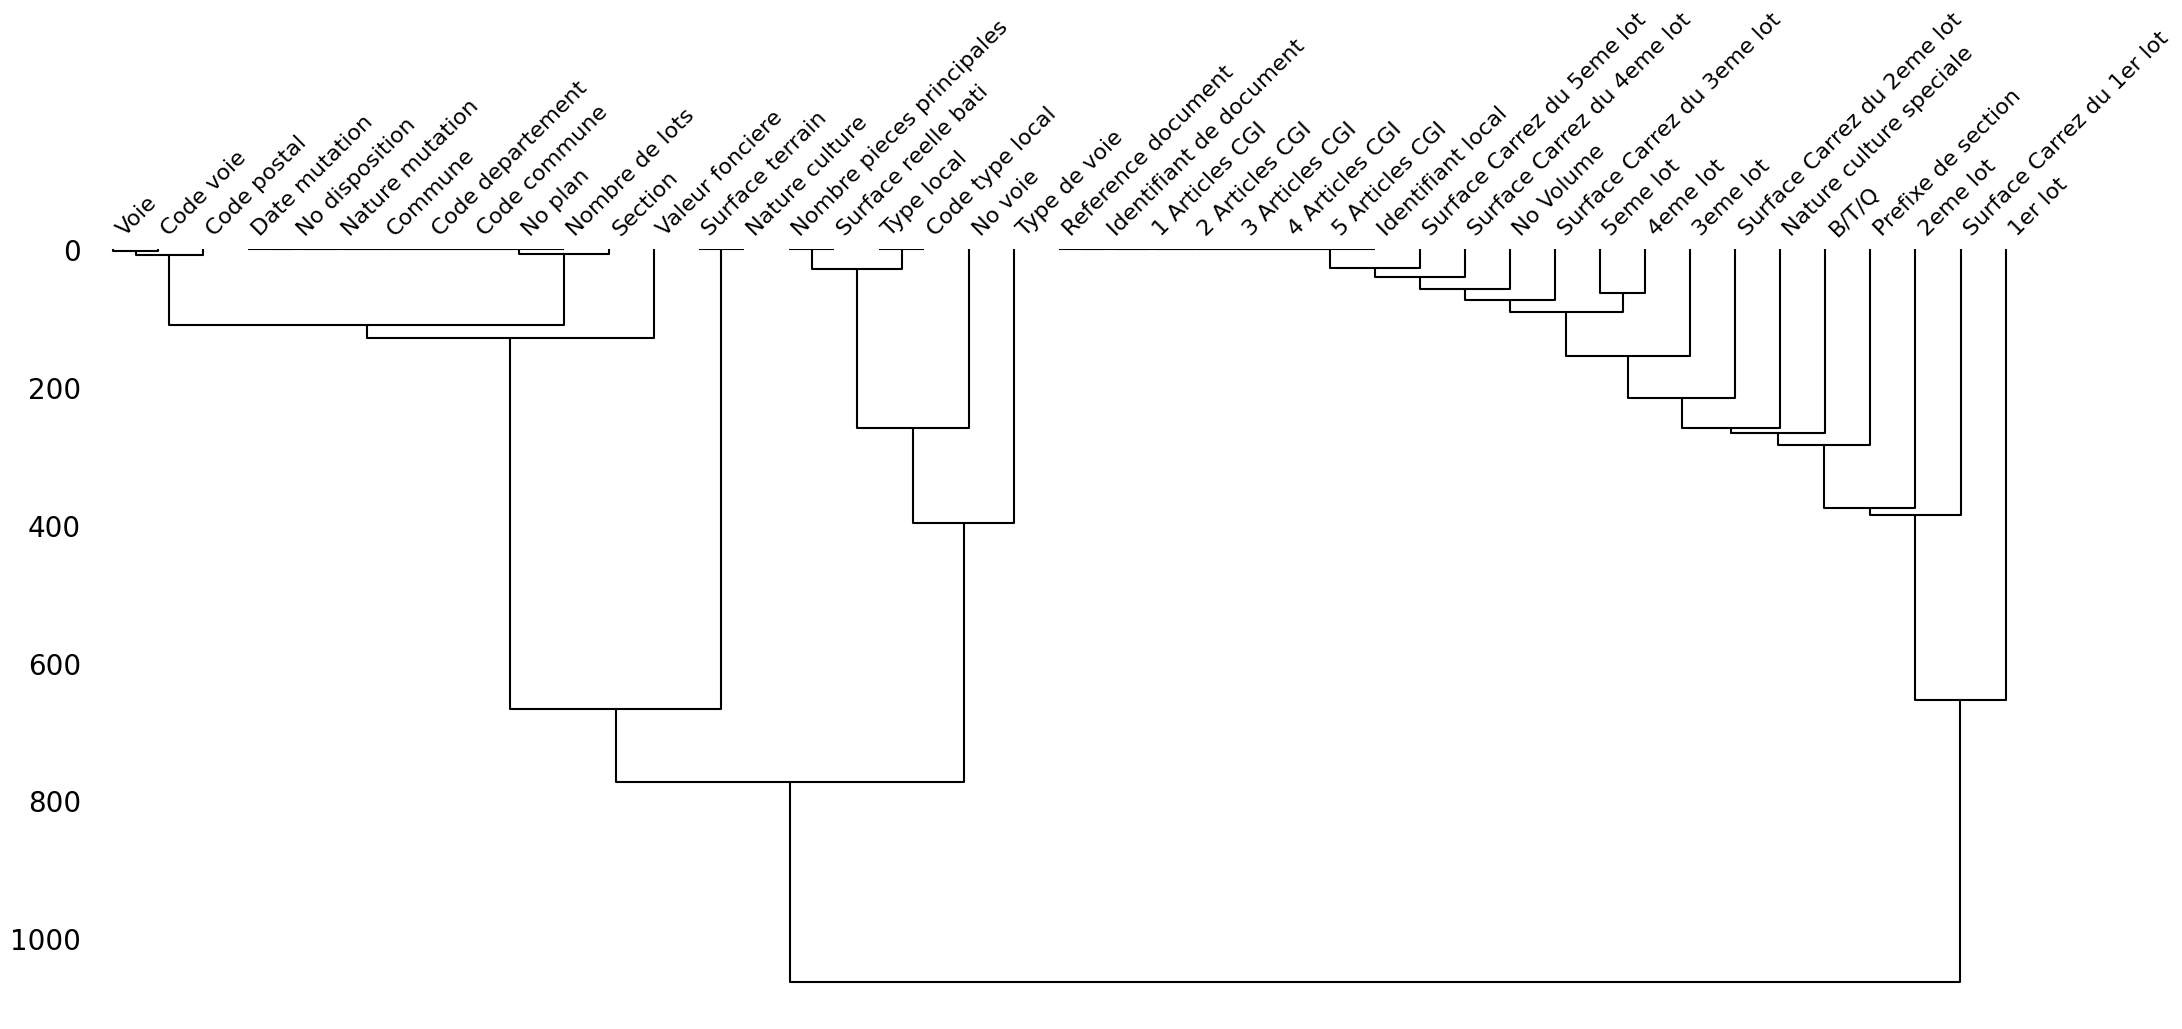

In [102]:
msno.dendrogram(df) 

#### Données unique no disposition

In [103]:
df['No disposition'].value_counts()


No disposition
1     1319994
2       56546
3        7330
4        1287
6         727
8         336
5         307
7          92
11         74
12         73
9          59
13         42
10         39
18         32
16         31
14         25
15         23
17          9
21          6
19          5
27          4
89          4
24          3
37          3
22          3
39          2
20          2
25          2
43          2
31          2
23          1
35          1
41          1
52          1
97          1
28          1
29          1
32          1
34          1
36          1
38          1
40          1
42          1
Name: count, dtype: int64

In [104]:
df['Date mutation'].value_counts()

Date mutation
31/03/2025    33757
30/04/2025    31302
28/03/2025    26825
29/04/2025    24919
28/02/2025    22896
              ...  
05/01/2025        2
27/04/2025        2
16/02/2025        1
12/01/2025        1
01/05/2025        1
Name: count, Length: 173, dtype: int64

In [105]:
df['Nature mutation'].value_counts()

Nature mutation
Vente                                 1310710
Vente en l'état futur d'achèvement      55448
Echange                                 16859
Vente terrain à bâtir                    2881
Adjudication                              928
Expropriation                             251
Name: count, dtype: int64

### Nettoyage des données

In [106]:
df_new = df.dropna(axis=1, how='all')

In [107]:
df_new

,No disposition,Date mutation,Nature mutation,Valeur fonciere,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,...,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
0,1,07/01/2025,Vente,468000.0,NaN,NaN,NaN,B078,FARGES,1550.0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,J,NaN,78.0
1,1,07/01/2025,Vente,468000.0,454.0,NaN,RUE,0090,DE LA REPUBLIQUE,1550.0,...,NaN,NaN,0,1.0,Maison,111.0,5.0,S,NaN,133.0
2,1,07/01/2025,Vente,468000.0,454.0,NaN,RUE,0090,DE LA REPUBLIQUE,1550.0,...,NaN,NaN,0,3.0,Dépendance,0.0,0.0,S,NaN,133.0
3,1,06/01/2025,Vente,180000.0,NaN,NaN,NaN,B158,LE VILLAGE,1200.0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,S,NaN,46.0
4,1,06/01/2025,Vente,180000.0,NaN,NaN,NaN,B158,LE VILLAGE,1200.0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,J,NaN,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1387072,1,27/06/2025,Vente,550000.0,84.0,NaN,RUE,9679,VERGNIAUD,75013.0,...,NaN,NaN,2,2.0,Appartement,61.0,3.0,NaN,NaN,NaN
1387073,1,27/06/2025,Vente,550386.1,24.0,NaN,RUE,7621,DE PONTOISE,75005.0,...,NaN,NaN,2,2.0,Appartement,47.0,2.0,NaN,NaN,NaN
1387074,1,27/06/2025,Vente,550386.1,24.0,NaN,RUE,7621,DE PONTOISE,75005.0,...,NaN,NaN,2,3.0,Dépendance,0.0,0.0,NaN,NaN,NaN
1387075,1,25/06/2025,Vente,24417580.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

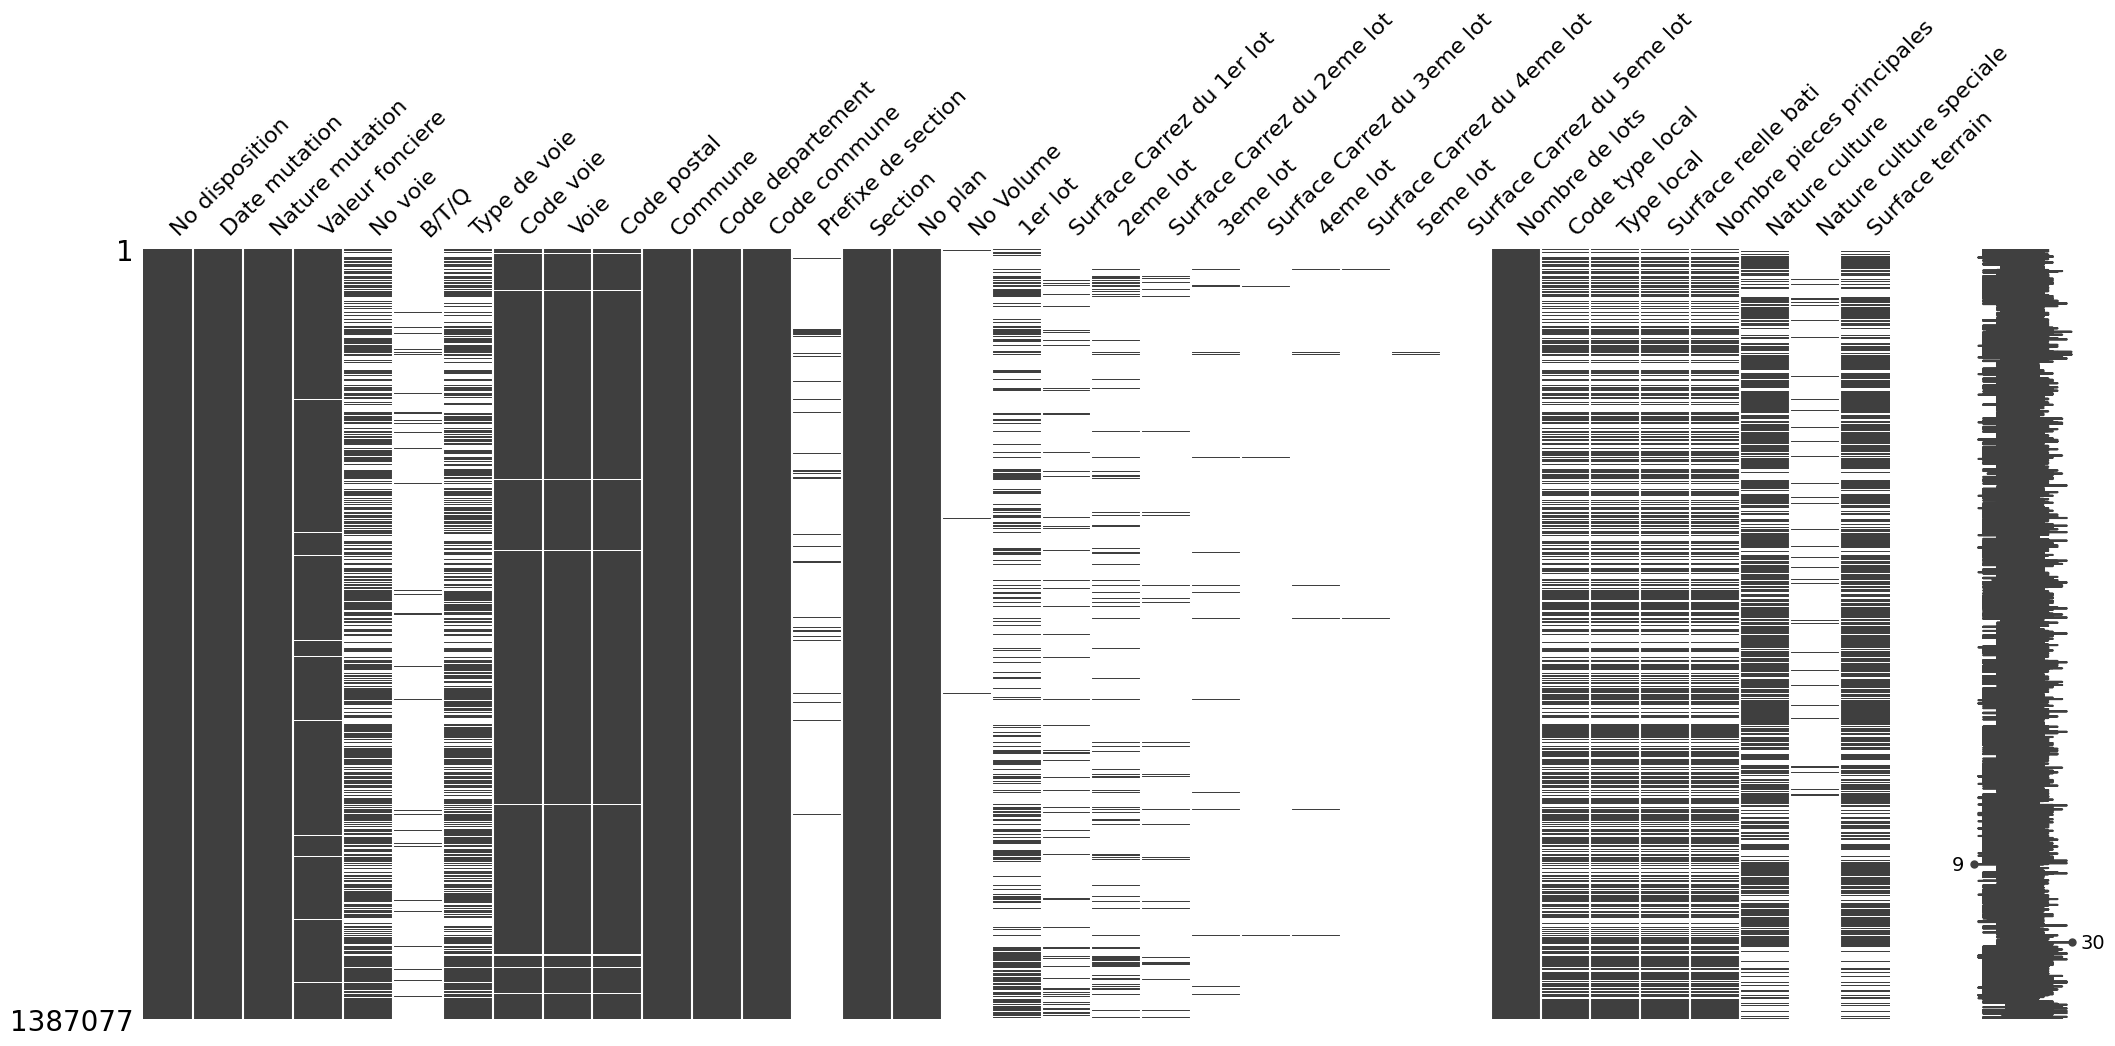

In [108]:
msno.matrix(df_new)

In [128]:
df_new[df_new["Prefixe de section"]!= 'NaN']

,No disposition,Date mutation,Nature mutation,Valeur fonciere,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,...,Nombre de lots,Code type local,Type local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain,Surface globale,Prix m2
0,1,07/01/2025,Vente,468000.0,0.0,0.0,0.0,B078,FARGES,1550.0,...,0,0.0,0.0,0.0,0.0,J,0.0,78.0,0.00,inf
1,1,07/01/2025,Vente,468000.0,454.0,0.0,RUE,0090,DE LA REPUBLIQUE,1550.0,...,0,1.0,Maison,111.0,5.0,S,0.0,133.0,0.00,inf
2,1,07/01/2025,Vente,468000.0,454.0,0.0,RUE,0090,DE LA REPUBLIQUE,1550.0,...,0,3.0,Dépendance,0.0,0.0,S,0.0,133.0,0.00,inf
3,1,06/01/2025,Vente,180000.0,0.0,0.0,0.0,B158,LE VILLAGE,1200.0,...,0,0.0,0.0,0.0,0.0,S,0.0,46.0,0.00,inf
4,1,06/01/2025,Vente,180000.0,0.0,0.0,0.0,B158,LE VILLAGE,1200.0,...,0,0.0,0.0,0.0,0.0,J,0.0,17.0,0.00,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1387072,1,27/06/2025,Vente,550000.0,84.0,0.0,RUE,9679,VERGNIAUD,75013.0,...,2,2.0,Appartement,61.0,3.0,0.0,0.0,0.0,0.00,inf
1387073,1,27/06/2025,Vente,550386.1,24.0,0.0,RUE,7621,DE PONTOISE,75005.0,...,2,2.0,Appartement,47.0,2.0,0.0,0.0,0.0,48.27,1.140224e+04
1387074,1,27/06/2025,Vente,550386.1,24.0,0.0,RUE,7621,DE PONTOISE,75005.0,...,2,3.0,Dépendance,0.0,0.0,0.0,0.0,0.0,48.27,1.140224e+04
1387075,1,25/06/2025,Vente,24417580.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,inf


In [109]:
df_new.fillna(0.0, inplace = True)

C:\Users\dd758\AppData\Local\Temp\ipykernel_13948\2361976242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new.fillna(0.0, inplace = True)


In [110]:
df_new[df_new["Type local"]=="Dépendance"]

,No disposition,Date mutation,Nature mutation,Valeur fonciere,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,...,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
2,1,07/01/2025,Vente,468000.0,454.0,0.0,RUE,0090,DE LA REPUBLIQUE,1550.0,...,0.0,0.0,0,3.0,Dépendance,0.0,0.0,S,0.0,133.0
7,1,06/01/2025,Vente,490000.0,459.0,B,CHE,0356,DU PETIT CORGENON,1310.0,...,0.0,0.0,0,3.0,Dépendance,0.0,0.0,S,0.0,500.0
8,1,06/01/2025,Vente,490000.0,459.0,B,CHE,0356,DU PETIT CORGENON,1310.0,...,0.0,0.0,0,3.0,Dépendance,0.0,0.0,S,0.0,500.0
10,1,06/01/2025,Vente,490000.0,459.0,B,CHE,0356,DU PETIT CORGENON,1310.0,...,0.0,0.0,0,3.0,Dépendance,0.0,0.0,S,0.0,500.0
11,1,06/01/2025,Vente,490000.0,459.0,B,CHE,0356,DU PETIT CORGENON,1310.0,...,0.0,0.0,0,3.0,Dépendance,0.0,0.0,AG,0.0,2452.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1387062,1,25/06/2025,Vente,375000.0,4.0,B,RUE,3479,FABRE D EGLANTINE,75012.0,...,0.0,0.0,2,3.0,Dépendance,0.0,0.0,0.0,0.0,0.0
1387065,1,25/06/2025,Vente,1370000.0,8.0,0.0,RUE,2240,CDT SCHLOESING,75016.0,...,0.0,0.0,1,3.0,Dépendance,0.0,0.0,0.0,0.0,0.0
1387070,1,27/06/2025,Vente,550000.0,84.0,0.0,RUE,9679,VERGNIAUD,75013.0,...,0.0,0.0,2,3.0,Dépendance,0.0,0.0,0.0,0.0,0.0
1387071,1,27/06/2025,Vente,550000.0,84.0,0.0,RUE,9679,VERGNIAUD,75013.0,...,0.0,0.0,1,3.0,Dépendance,0.0,0.0,0.0,0.0,0.0


<Axes: >

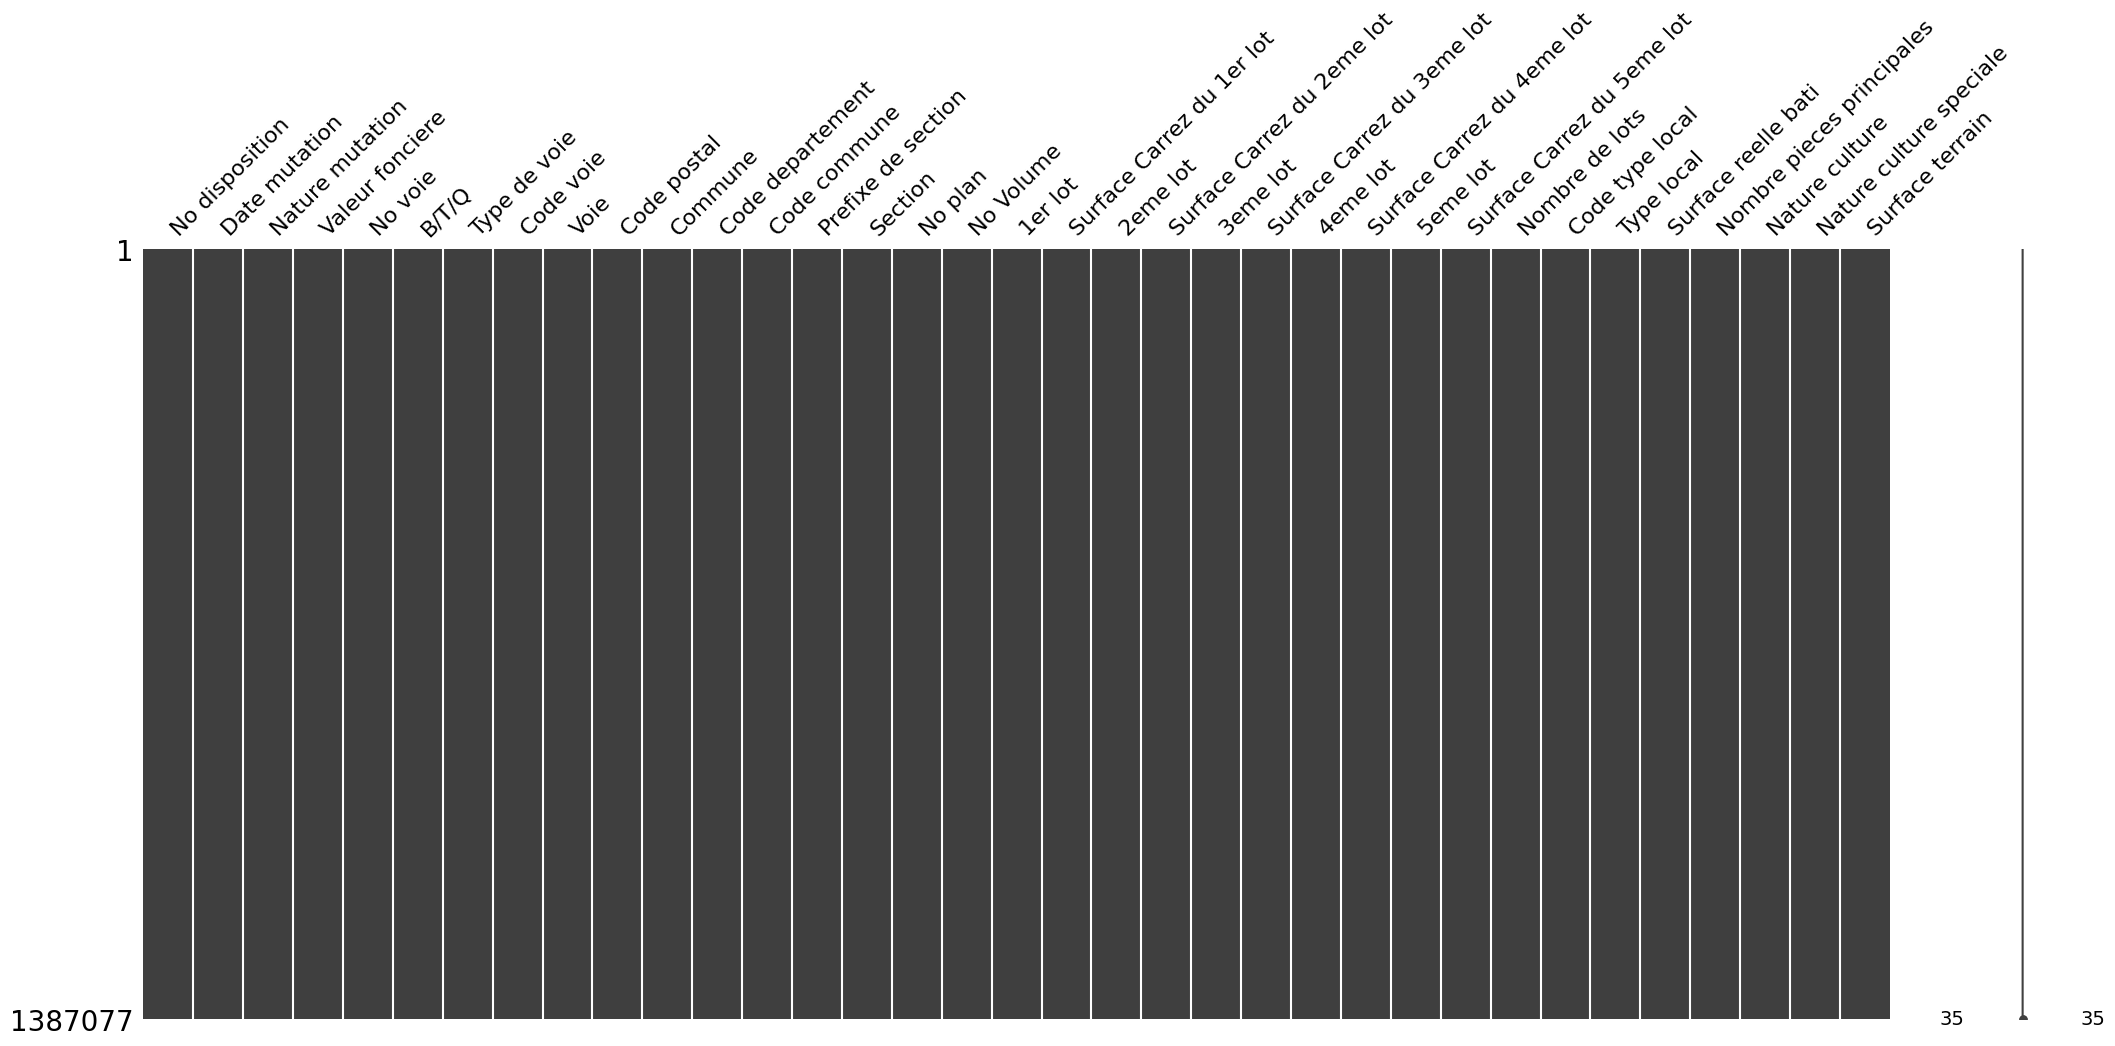

In [111]:
msno.matrix(df_new)

<Axes: >

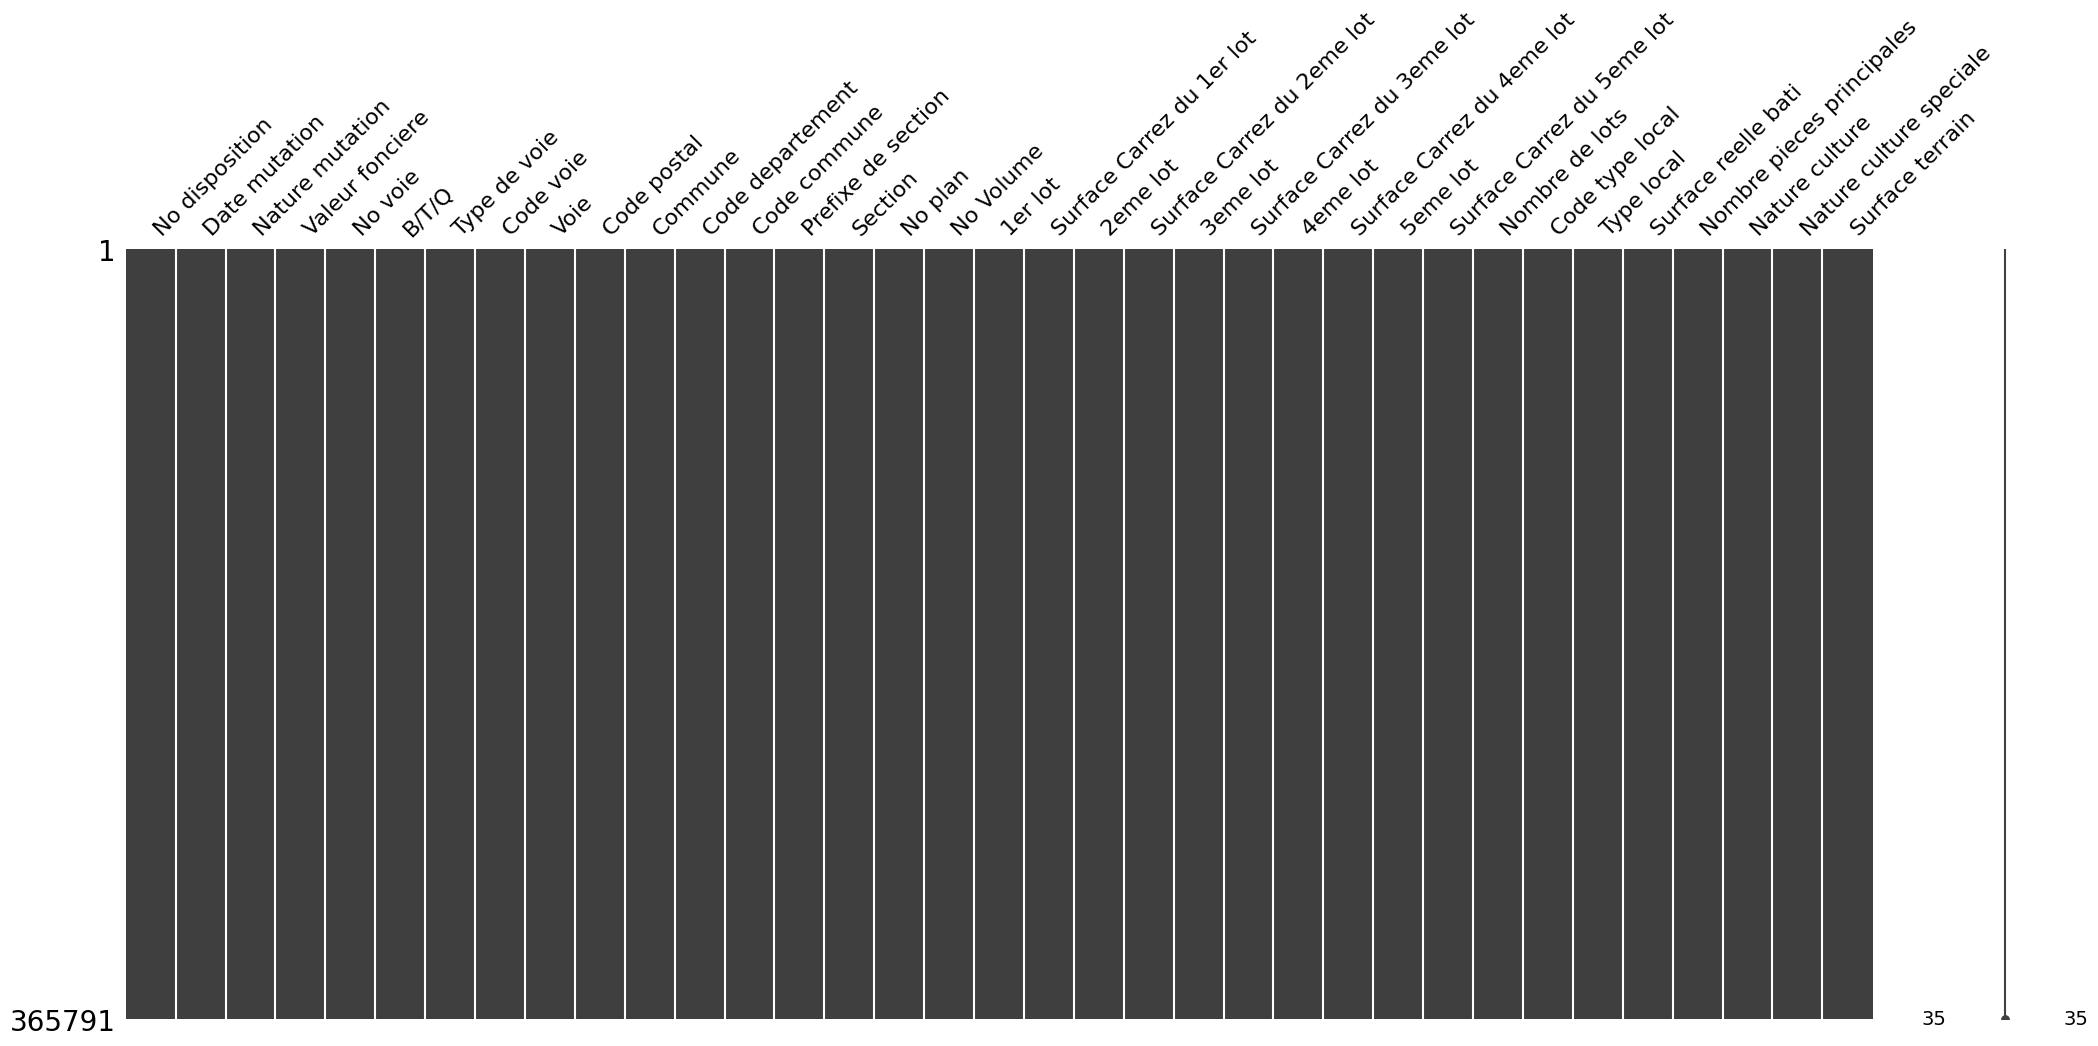

In [112]:
msno.matrix(df_new[df_new["Type local"]=="Dépendance"])

<Axes: >

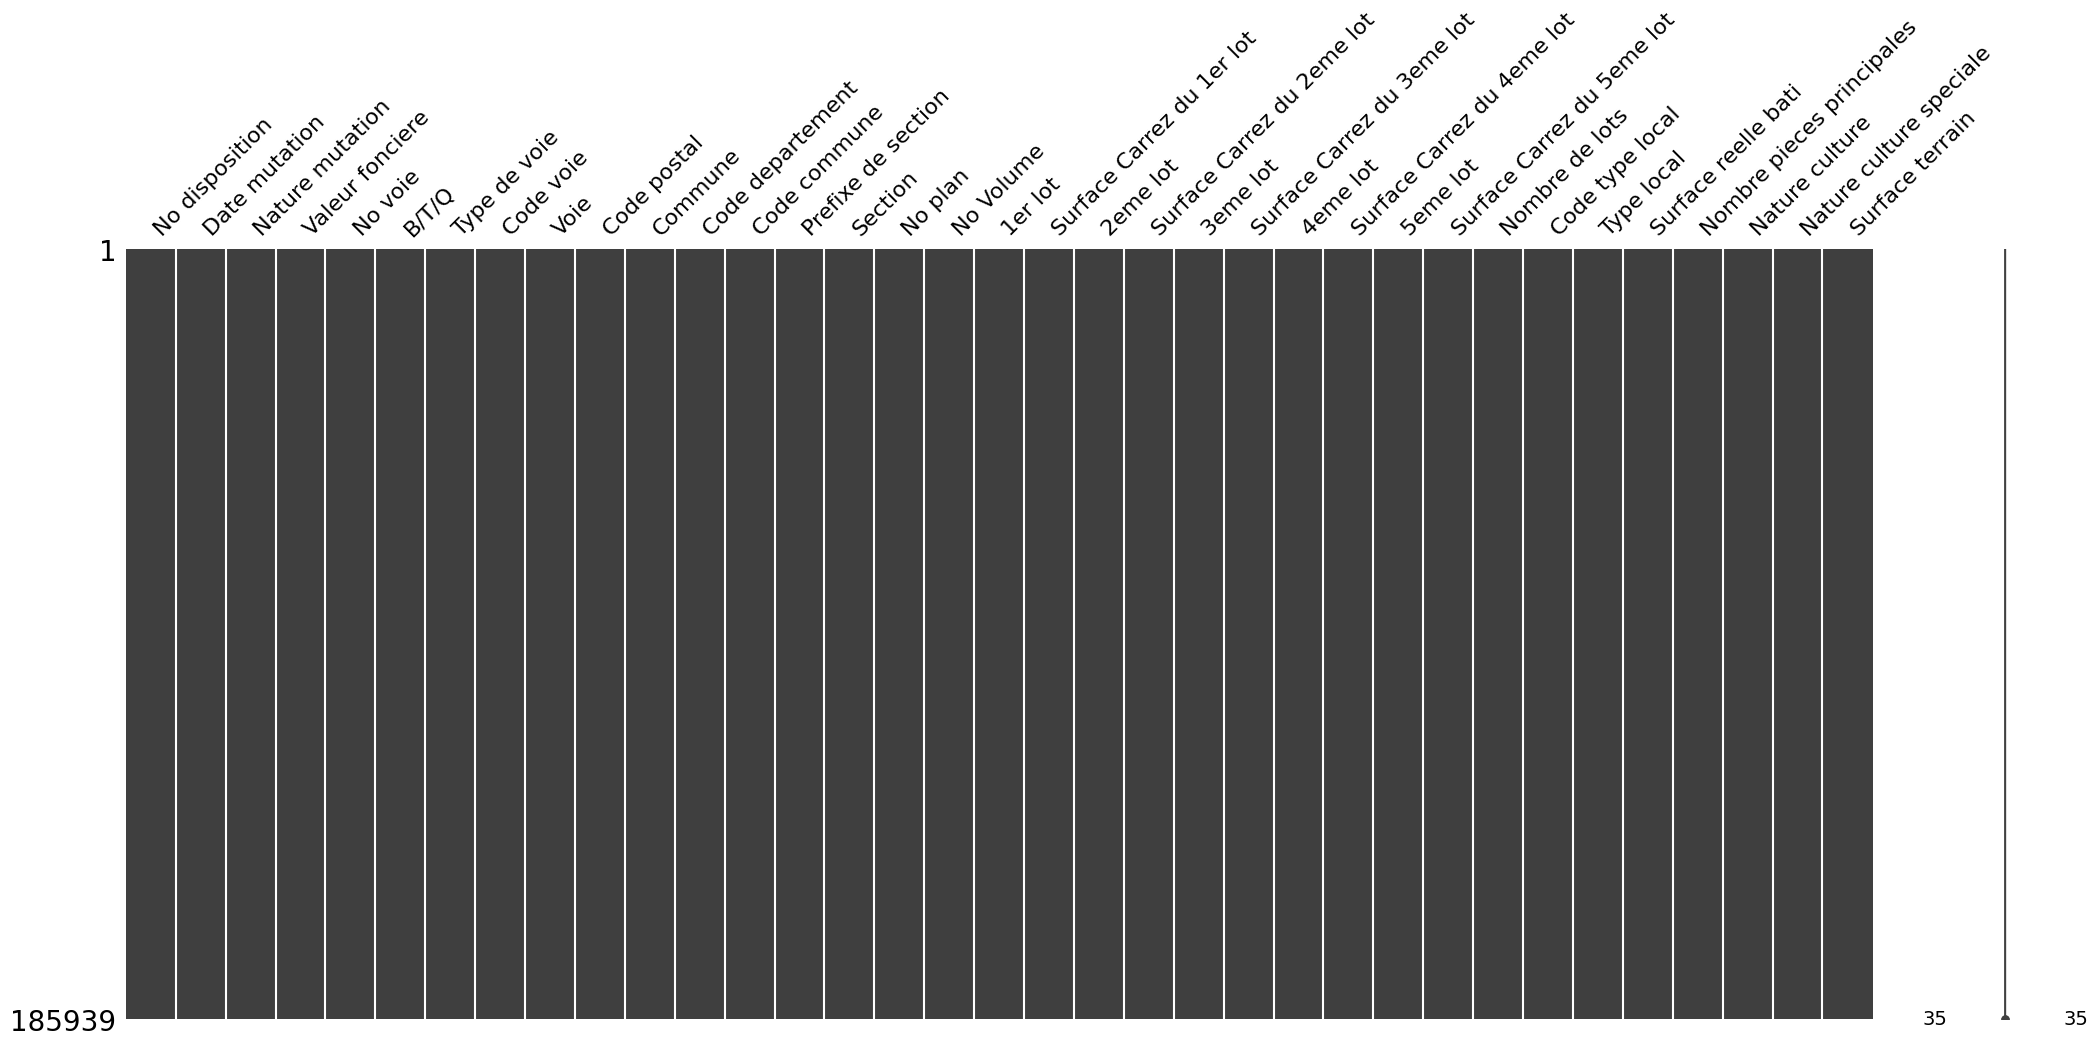

In [113]:
msno.matrix(df_new[df_new["Type local"]=="Appartement"])

In [114]:
df_new.duplicated().sum()

np.int64(96897)

In [115]:
df_new.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
1387072    False
1387073    False
1387074    False
1387075    False
1387076    False
Length: 1387077, dtype: bool

In [116]:
df_new.drop_duplicates(inplace=True)

C:\Users\dd758\AppData\Local\Temp\ipykernel_13948\3069802320.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new.drop_duplicates(inplace=True)


In [117]:
df_new.duplicated().sum()

np.int64(0)

In [118]:
df_new["Valeur fonciere"].max()

np.float64(317290816.0)

In [119]:
df_new["Surface globale"] = df_new["Surface Carrez du 1er lot"] + df_new["Surface Carrez du 2eme lot"] + df_new["Surface Carrez du 3eme lot"] + df_new["Surface Carrez du 4eme lot"] + df_new["Surface Carrez du 5eme lot"]

C:\Users\dd758\AppData\Local\Temp\ipykernel_13948\1588445054.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new["Surface globale"] = df_new["Surface Carrez du 1er lot"] + df_new["Surface Carrez du 2eme lot"] + df_new["Surface Carrez du 3eme lot"] + df_new["Surface Carrez du 4eme lot"] + df_new["Surface Carrez du 5eme lot"]


In [120]:
df_new["Prix m2"] = df_new["Valeur fonciere"]/df_new["Surface globale"]

C:\Users\dd758\AppData\Local\Temp\ipykernel_13948\844859906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new["Prix m2"] = df_new["Valeur fonciere"]/df_new["Surface globale"]


In [121]:
df_new[df_new["Surface globale"] > 0][["Surface globale", "Valeur fonciere", "Prix m2", "Code postal"]]

,Surface globale,Valeur fonciere,Prix m2,Code postal
18,12.00,183000.0,15250.000000,1170.0
19,13.09,183000.0,13980.137510,1170.0
20,35.74,183000.0,5120.313374,1170.0
25,79.10,543510.0,6871.175727,1210.0
29,78.91,173000.0,2192.371056,1290.0
...,...,...,...,...
1387053,75.33,540000.0,7168.458781,75016.0
1387055,75.33,540000.0,7168.458781,75016.0
1387061,91.08,835000.0,9167.764603,75011.0
1387073,48.27,550386.1,11402.239486,75005.0


In [122]:
df_new["Prix m2"]

0                   inf
1                   inf
2                   inf
3                   inf
4                   inf
               ...     
1387072             inf
1387073    1.140224e+04
1387074    1.140224e+04
1387075             inf
1387076             inf
Name: Prix m2, Length: 1290180, dtype: float64

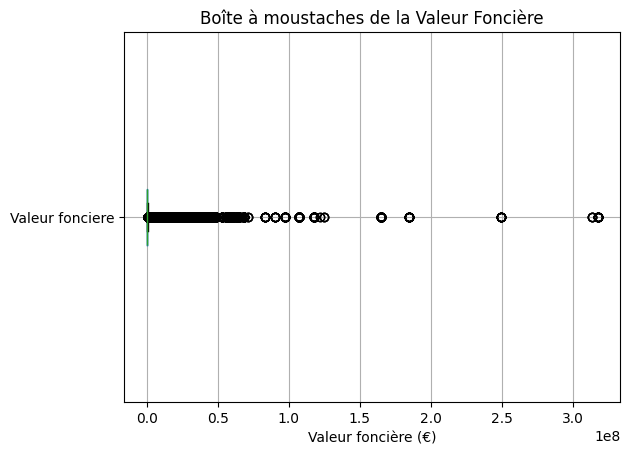

In [123]:
df_new.boxplot(column="Valeur fonciere", vert=False)
plt.title("Boîte à moustaches de la Valeur Foncière")
plt.xlabel("Valeur foncière (€)")
plt.show()

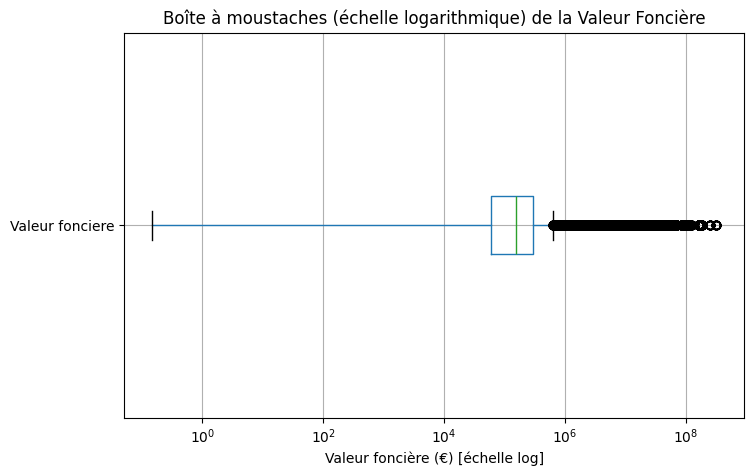

In [124]:
plt.figure(figsize=(8, 5))
df.boxplot(column="Valeur fonciere", vert=False)
plt.xscale("log")  # Échelle logarithmique
plt.title("Boîte à moustaches (échelle logarithmique) de la Valeur Foncière")
plt.xlabel("Valeur foncière (€) [échelle log]")
plt.show()

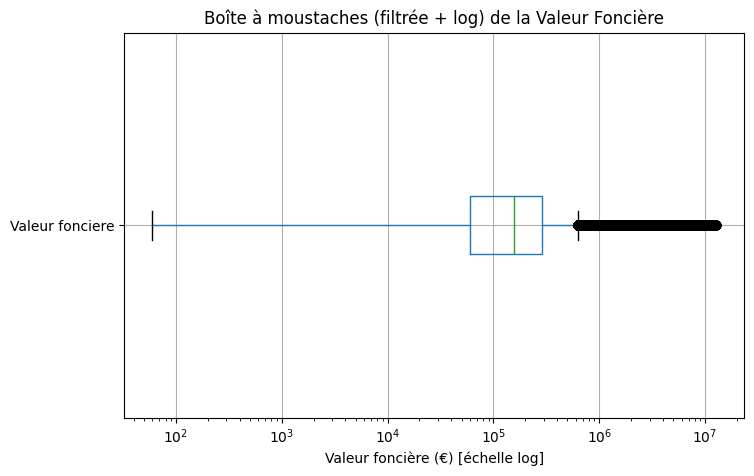

In [125]:
plt.figure(figsize=(8,5))
df_filtre.boxplot(column="Valeur fonciere", vert=False)
plt.xscale("log")
plt.title("Boîte à moustaches (filtrée + log) de la Valeur Foncière")
plt.xlabel("Valeur foncière (€) [échelle log]")
plt.show()


In [126]:
df_new[df_new.duplicated()]

,No disposition,Date mutation,Nature mutation,Valeur fonciere,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,...,Nombre de lots,Code type local,Type local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain,Surface globale,Prix m2
